# Flu Data Build — Illinois Weekly ILI + Weather

This notebook builds the base weekly dataset for the flu outbreak prediction project.

## Goals
- Load raw Illinois flu surveillance data
- Load raw historical weather data
- Clean and align both sources to weekly resolution
- Merge them into one modeling-ready weekly table
- Save interim and processed outputs for downstream notebooks

## Inputs
### Disease data
- Source: Delphi Epidata / CDC FluView-backed weekly flu data
- Signal used: `wili` / `ili`
- Region: Illinois

### Weather data
- Source: Open-Meteo historical weather archive
- Location used in v1: Springfield, Illinois
- Variables:
  - `temperature_2m_max`
  - `temperature_2m_min`
  - `precipitation_sum`
  - `wind_speed_10m_max`
  - `shortwave_radiation_sum`

## Outputs
### Interim
- `flu_weekly_disease.parquet`
- `flu_daily_weather.parquet`
- `flu_weekly_weather.parquet`

### Processed
- `flu_weekly_merged.parquet`
- `flu_weekly_merged.csv`

## Notes
- This notebook is for **data build only**
- Outbreak labeling, lag features, and modeling are handled later in `10_flu_model_exploration.ipynb`
- The weekly alignment uses CDC/MMWR epiweeks for flu and weekly aggregated weather

In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path("..").resolve()))

from config import PATHS, FILES, savefig, save_parquet, save_csv, print_config_summary

print_config_summary()

===== CONFIG SUMMARY =====
Base Dir: /Users/suvo/Projects/disease-outbreak
Default Disease: flu
Default Region: illinois
Forecast Horizons: [1, 2, 3, 4]
Default Lags: [1, 2, 3, 4]
Default Outbreak Quantile: 0.85
Raw Data Dir: /Users/suvo/Projects/disease-outbreak/data/raw
Interim Data Dir: /Users/suvo/Projects/disease-outbreak/data/interim
Processed Data Dir: /Users/suvo/Projects/disease-outbreak/data/processed
Figures Dir: /Users/suvo/Projects/disease-outbreak/outputs/figures
Tables Dir: /Users/suvo/Projects/disease-outbreak/outputs/tables
Models Dir: /Users/suvo/Projects/disease-outbreak/outputs/models
Flu Raw JSON: /Users/suvo/Projects/disease-outbreak/data/raw/flu/fluview_il_201040_202652.json
Flu Weather Raw JSON: /Users/suvo/Projects/disease-outbreak/data/raw/flu/weather_openmeteo_springfield_il_2010-10-01_2026-04-10.json


In [2]:
from pathlib import Path
import json
import pandas as pd

In [3]:
RAW_DIR = Path("../data/raw/flu")

flu_path = RAW_DIR / "fluview_il_201040_202652.json"
weather_path = RAW_DIR / "weather_openmeteo_springfield_il_2010-10-01_2026-04-10.json"

print(flu_path)
print(weather_path)
print(flu_path.exists(), weather_path.exists())

../data/raw/flu/fluview_il_201040_202652.json
../data/raw/flu/weather_openmeteo_springfield_il_2010-10-01_2026-04-10.json
True True


In [4]:
with open(flu_path, "r") as f:
    flu_json = json.load(f)

with open(weather_path, "r") as f:
    weather_json = json.load(f)

print("FLU TOP-LEVEL KEYS:")
print(flu_json.keys())

print("\nWEATHER TOP-LEVEL KEYS:")
print(weather_json.keys())

FLU TOP-LEVEL KEYS:
dict_keys(['epidata', 'result', 'message'])

WEATHER TOP-LEVEL KEYS:
dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])


In [5]:
print("FLU SAMPLE:")
for k, v in flu_json.items():
    if isinstance(v, list):
        print(k, f"list length = {len(v)}")
    else:
        print(k, v if isinstance(v, (int, float, str)) else type(v))

FLU SAMPLE:
epidata list length = 808
result 1
message success


In [6]:
print("WEATHER SAMPLE:")
for k, v in weather_json.items():
    if isinstance(v, list):
        print(k, f"list length = {len(v)}")
    elif isinstance(v, dict):
        print(k, f"dict keys = {list(v.keys())[:10]}")
    else:
        print(k, v)

WEATHER SAMPLE:
latitude 39.753952
longitude 89.62448
generationtime_ms 794.9919700622559
utc_offset_seconds -18000
timezone America/Chicago
timezone_abbreviation GMT-5
elevation 789.0
daily_units dict keys = ['time', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'wind_speed_10m_max', 'shortwave_radiation_sum']
daily dict keys = ['time', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'wind_speed_10m_max', 'shortwave_radiation_sum']


In [7]:
flu_json.get("result"), flu_json.get("message")

(1, 'success')

In [8]:
flu_df = pd.DataFrame(flu_json["epidata"])
flu_df.head()

,release_date,region,issue,epiweek,lag,num_ili,num_patients,num_providers,num_age_0,num_age_1,num_age_2,num_age_3,num_age_4,num_age_5,wili,ili
0,2017-10-24,il,201740,201040,365,505,39390,74,None,None,None,None,None,None,1.28205,1.28205
1,2017-10-24,il,201740,201041,364,600,41354,76,None,None,None,None,None,None,1.45089,1.45089
2,2017-10-24,il,201740,201042,363,644,41122,76,None,None,None,None,None,None,1.56607,1.56607
3,2017-10-24,il,201740,201043,362,623,42741,79,None,None,None,None,None,None,1.45762,1.45762
4,2017-10-24,il,201740,201044,361,625,41966,79,None,None,None,None,None,None,1.48930,1.48930


In [9]:
flu_df.columns.tolist()

['release_date',
 'region',
 'issue',
 'epiweek',
 'lag',
 'num_ili',
 'num_patients',
 'num_providers',
 'num_age_0',
 'num_age_1',
 'num_age_2',
 'num_age_3',
 'num_age_4',
 'num_age_5',
 'wili',
 'ili']

In [10]:
daily_weather = pd.DataFrame(weather_json["daily"])
daily_weather.head()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum
0,2010-10-01,26.1,8.9,0.0,36.4,19.35
1,2010-10-02,25.0,9.2,0.0,12.1,18.90
2,2010-10-03,25.6,14.7,0.0,13.8,16.38
3,2010-10-04,27.7,10.8,0.0,16.3,18.44
4,2010-10-05,28.3,12.7,0.0,16.9,18.60


In [11]:
daily_weather.columns.tolist(), daily_weather.shape

(['time',
  'temperature_2m_max',
  'temperature_2m_min',
  'precipitation_sum',
  'wind_speed_10m_max',
  'shortwave_radiation_sum'],
 (5671, 6))

In [12]:
# Keep latest issue for each epiweek
flu_df = flu_df.sort_values(["epiweek", "issue"])
flu_df = flu_df.groupby("epiweek").tail(1).reset_index(drop=True)

print(flu_df.shape)
flu_df.head()

(808, 16)


,release_date,region,issue,epiweek,lag,num_ili,num_patients,num_providers,num_age_0,num_age_1,num_age_2,num_age_3,num_age_4,num_age_5,wili,ili
0,2017-10-24,il,201740,201040,365,505,39390,74,None,None,None,None,None,None,1.28205,1.28205
1,2017-10-24,il,201740,201041,364,600,41354,76,None,None,None,None,None,None,1.45089,1.45089
2,2017-10-24,il,201740,201042,363,644,41122,76,None,None,None,None,None,None,1.56607,1.56607
3,2017-10-24,il,201740,201043,362,623,42741,79,None,None,None,None,None,None,1.45762,1.45762
4,2017-10-24,il,201740,201044,361,625,41966,79,None,None,None,None,None,None,1.48930,1.48930


In [13]:
from epiweeks import Week

def epiweek_to_date(epiweek):
    return pd.Timestamp(Week.fromstring(str(int(epiweek))).startdate())

flu_df["week_start"] = flu_df["epiweek"].apply(epiweek_to_date)

display(flu_df[["epiweek", "week_start"]].head(10))

,epiweek,week_start
0,201040,2010-10-03
1,201041,2010-10-10
2,201042,2010-10-17
3,201043,2010-10-24
4,201044,2010-10-31
5,201045,2010-11-07
6,201046,2010-11-14
7,201047,2010-11-21
8,201048,2010-11-28
9,201049,2010-12-05


In [14]:
daily_weather["time"] = pd.to_datetime(daily_weather["time"])
daily_weather = daily_weather.sort_values("time")
daily_weather = daily_weather.set_index("time")

In [16]:
weekly_weather = (
    daily_weather
    .resample("W-SUN")
    .agg({
        "temperature_2m_max": "mean",
        "temperature_2m_min": "mean",
        "precipitation_sum": "sum",
        "wind_speed_10m_max": "mean",
        "shortwave_radiation_sum": "mean",
    })
    .reset_index()
    .rename(columns={"time": "week_start"})
)

print("weekly_weather shape:", weekly_weather.shape)
display(weekly_weather.head())

weekly_weather shape: (811, 6)


,week_start,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum
0,2010-10-03,25.566667,10.933333,0.0,20.766667,18.210000
1,2010-10-10,24.557143,9.700000,0.2,31.342857,17.417143
2,2010-10-17,22.314286,7.571429,0.0,16.700000,16.500000
3,2010-10-24,19.057143,6.557143,7.4,25.342857,12.132857
4,2010-10-31,11.928571,0.585714,0.0,14.271429,13.637143


In [17]:
merged_df = pd.merge(
    flu_df,
    weekly_weather,
    on="week_start",
    how="inner"
)

print(merged_df.shape)
merged_df.head()

(808, 22)


,release_date,region,issue,epiweek,lag,num_ili,num_patients,num_providers,num_age_0,num_age_1,...,num_age_4,num_age_5,wili,ili,week_start,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum
0,2017-10-24,il,201740,201040,365,505,39390,74,None,None,...,None,None,1.28205,1.28205,2010-10-03,25.566667,10.933333,0.0,20.766667,18.210000
1,2017-10-24,il,201740,201041,364,600,41354,76,None,None,...,None,None,1.45089,1.45089,2010-10-10,24.557143,9.700000,0.2,31.342857,17.417143
2,2017-10-24,il,201740,201042,363,644,41122,76,None,None,...,None,None,1.56607,1.56607,2010-10-17,22.314286,7.571429,0.0,16.700000,16.500000
3,2017-10-24,il,201740,201043,362,623,42741,79,None,None,...,None,None,1.45762,1.45762,2010-10-24,19.057143,6.557143,7.4,25.342857,12.132857
4,2017-10-24,il,201740,201044,361,625,41966,79,None,None,...,None,None,1.48930,1.48930,2010-10-31,11.928571,0.585714,0.0,14.271429,13.637143


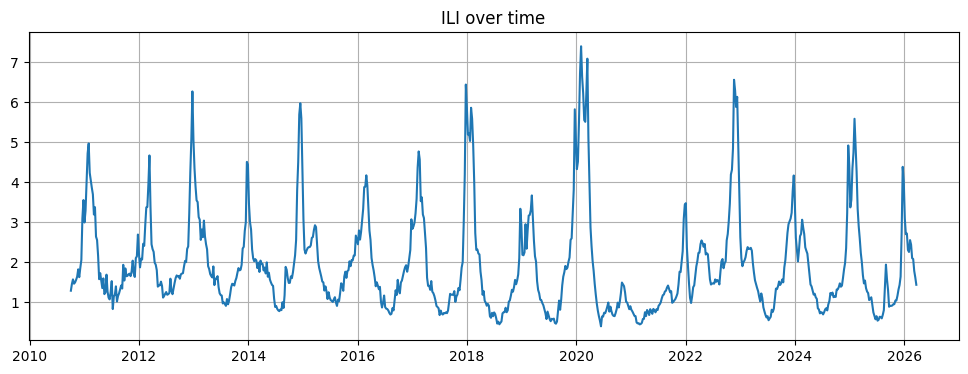

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(merged_df["week_start"], merged_df["wili"])
plt.title("ILI over time")
plt.grid(True)
plt.show()

In [19]:
threshold = merged_df["wili"].quantile(0.85)

merged_df["outbreak"] = (merged_df["wili"] >= threshold).astype(int)

print("Threshold:", threshold)
print("Outbreak rate:", merged_df["outbreak"].mean())

Threshold: 3.0369365
Outbreak rate: 0.15099009900990099


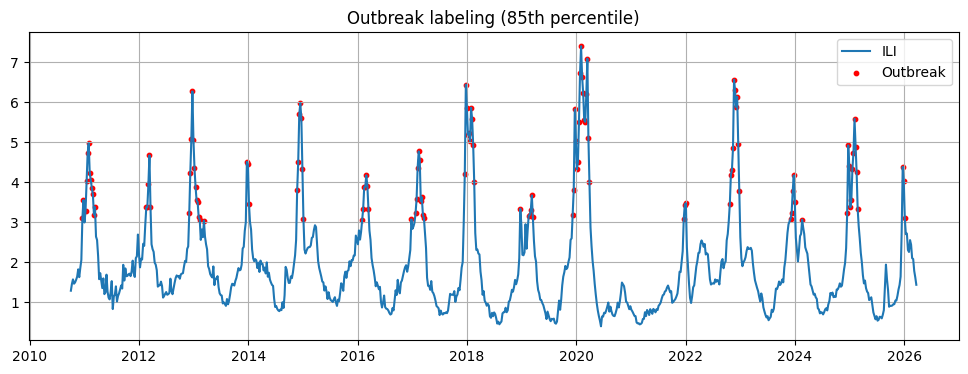

In [20]:
plt.figure(figsize=(12,4))
plt.plot(merged_df["week_start"], merged_df["wili"], label="ILI")

plt.scatter(
    merged_df["week_start"][merged_df["outbreak"] == 1],
    merged_df["wili"][merged_df["outbreak"] == 1],
    color="red",
    s=10,
    label="Outbreak"
)

plt.legend()
plt.title("Outbreak labeling (85th percentile)")
plt.grid(True)
plt.show()

In [21]:
save_parquet(flu_df, FILES["flu_weekly_disease"])
save_parquet(daily_weather, FILES["flu_daily_weather"])
save_parquet(weekly_weather, FILES["flu_weekly_weather"])
save_parquet(merged_df, FILES["flu_weekly_merged_parquet"])
save_csv(merged_df, FILES["flu_weekly_merged_csv"])

Saved parquet: /Users/suvo/Projects/disease-outbreak/data/interim/flu/flu_weekly_disease.parquet
Saved parquet: /Users/suvo/Projects/disease-outbreak/data/interim/flu/flu_daily_weather.parquet
Saved parquet: /Users/suvo/Projects/disease-outbreak/data/interim/flu/flu_weekly_weather.parquet
Saved parquet: /Users/suvo/Projects/disease-outbreak/data/processed/flu/flu_weekly_merged.parquet
Saved csv: /Users/suvo/Projects/disease-outbreak/data/processed/flu/flu_weekly_merged.csv


PosixPath('/Users/suvo/Projects/disease-outbreak/data/processed/flu/flu_weekly_merged.csv')